In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
# machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

In [3]:
train_df = pd.read_csv('/kaggle/input/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/titanic/test.csv')

display(train_df.head())
print(train_df.shape)
print("#"*50)

display(test_df.head())
print(test_df.shape)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


(891, 12)
##################################################


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


(418, 11)


In [4]:
display(train_df.info())
display(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


None

Survived
0    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
1    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
dtype: object

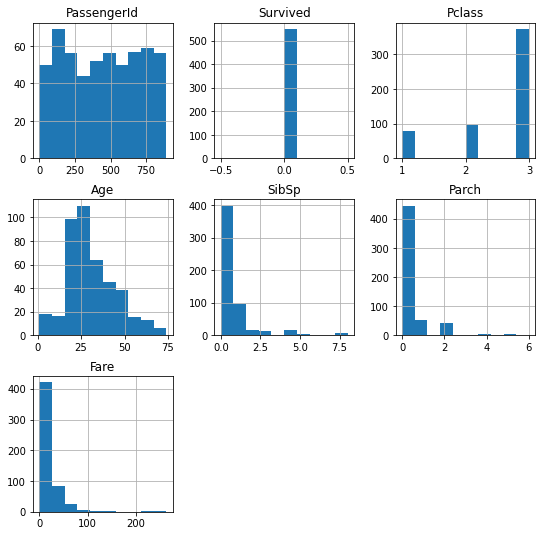

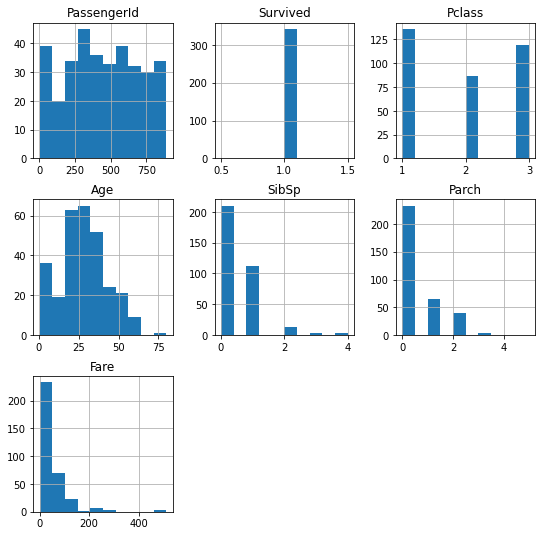

In [5]:
train_df.groupby('Survived').hist(figsize=(9,9))

<AxesSubplot:>

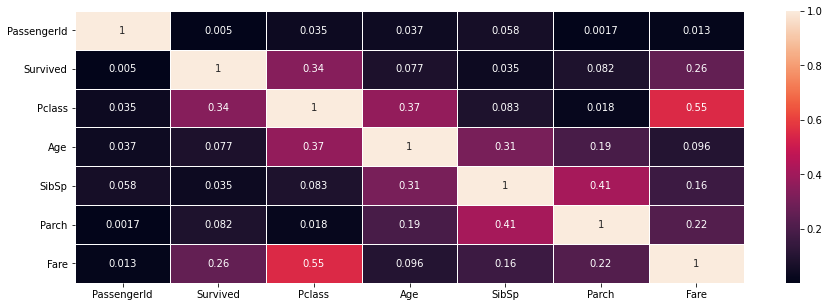

In [6]:
fig, ax = plt.subplots(figsize=(15,5))
corr_matrix = train_df.corr().abs()
sns.heatmap(corr_matrix, annot=True, linewidths=.5)

In [7]:
train_df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [8]:
#train_df  Cabin
train_df=train_df.drop(['Ticket','Name'],axis=1)
test_df=test_df.drop(['Ticket','Name'],axis=1)

display(train_df.head())
print(train_df.info())
display(test_df.head())
print(test_df.info())

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,71.2833,C85,C
2,3,1,3,female,26.0,0,0,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,53.1000,C123,S
4,5,0,3,male,35.0,0,0,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Cabin        204 non-null    object 
 9   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB
None


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,892,3,male,34.5,0,0,7.8292,NaN,Q
1,893,3,female,47.0,1,0,7.0000,NaN,S
2,894,2,male,62.0,0,0,9.6875,NaN,Q
3,895,3,male,27.0,0,0,8.6625,NaN,S
4,896,3,female,22.0,1,1,12.2875,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   Age          332 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         417 non-null    float64
 7   Cabin        91 non-null     object 
 8   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 29.5+ KB
None


In [9]:
train_df['CabinNew'] = train_df["Cabin"].notna()
test_df['CabinNew'] = test_df["Cabin"].notna()
#pd.isna(train_df["Cabin"])
display(train_df.head())
print(train_df.info())

display(test_df.head())
print(test_df.info())

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,CabinNew
0,1,0,3,male,22.0,1,0,7.2500,NaN,S,False
1,2,1,1,female,38.0,1,0,71.2833,C85,C,True
2,3,1,3,female,26.0,0,0,7.9250,NaN,S,False
3,4,1,1,female,35.0,1,0,53.1000,C123,S,True
4,5,0,3,male,35.0,0,0,8.0500,NaN,S,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Cabin        204 non-null    object 
 9   Embarked     889 non-null    object 
 10  CabinNew     891 non-null    bool   
dtypes: bool(1), float64(2), int64(5), object(3)
memory usage: 70.6+ KB
None


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,CabinNew
0,892,3,male,34.5,0,0,7.8292,NaN,Q,False
1,893,3,female,47.0,1,0,7.0000,NaN,S,False
2,894,2,male,62.0,0,0,9.6875,NaN,Q,False
3,895,3,male,27.0,0,0,8.6625,NaN,S,False
4,896,3,female,22.0,1,1,12.2875,NaN,S,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   Age          332 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         417 non-null    float64
 7   Cabin        91 non-null     object 
 8   Embarked     418 non-null    object 
 9   CabinNew     418 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(3)
memory usage: 29.9+ KB
None


In [10]:
train_df=train_df.drop(['Cabin'],axis=1)
test_df=test_df.drop(['Cabin'],axis=1)
display(train_df.head())
print(train_df.info())
display(test_df.head())
print(test_df.info())

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinNew
0,1,0,3,male,22.0,1,0,7.2500,S,False
1,2,1,1,female,38.0,1,0,71.2833,C,True
2,3,1,3,female,26.0,0,0,7.9250,S,False
3,4,1,1,female,35.0,1,0,53.1000,S,True
4,5,0,3,male,35.0,0,0,8.0500,S,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
 9   CabinNew     891 non-null    bool   
dtypes: bool(1), float64(2), int64(5), object(2)
memory usage: 63.6+ KB
None


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinNew
0,892,3,male,34.5,0,0,7.8292,Q,False
1,893,3,female,47.0,1,0,7.0000,S,False
2,894,2,male,62.0,0,0,9.6875,Q,False
3,895,3,male,27.0,0,0,8.6625,S,False
4,896,3,female,22.0,1,1,12.2875,S,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   Age          332 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         417 non-null    float64
 7   Embarked     418 non-null    object 
 8   CabinNew     418 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 26.7+ KB
None


In [11]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
CabinNew         0
dtype: int64
PassengerId     0
Pclass          0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            1
Embarked        0
CabinNew        0
dtype: int64


In [12]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].mean())
train_df['Embarked'] = train_df['Embarked'].fillna('S')

test_df['Age'] = test_df['Age'].fillna(train_df['Age'].mean())
test_df['Embarked'] = test_df['Embarked'].fillna('S')
test_df['Fare'].fillna(test_df['Fare'].dropna().median(), inplace=True)

display(train_df.head())
print(train_df.info())
display(test_df.head())
print(test_df.info())

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinNew
0,1,0,3,male,22.0,1,0,7.2500,S,False
1,2,1,1,female,38.0,1,0,71.2833,C,True
2,3,1,3,female,26.0,0,0,7.9250,S,False
3,4,1,1,female,35.0,1,0,53.1000,S,True
4,5,0,3,male,35.0,0,0,8.0500,S,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    object 
 9   CabinNew     891 non-null    bool   
dtypes: bool(1), float64(2), int64(5), object(2)
memory usage: 63.6+ KB
None


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinNew
0,892,3,male,34.5,0,0,7.8292,Q,False
1,893,3,female,47.0,1,0,7.0000,S,False
2,894,2,male,62.0,0,0,9.6875,Q,False
3,895,3,male,27.0,0,0,8.6625,S,False
4,896,3,female,22.0,1,1,12.2875,S,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         418 non-null    float64
 7   Embarked     418 non-null    object 
 8   CabinNew     418 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 26.7+ KB
None


In [13]:
train_df['Sex'] = train_df.Sex.map({'male':0,'female':1})
train_df['Embarked'] = train_df.Embarked.map({'S':0,'C':1,'Q':2})

test_df['Sex'] = test_df.Sex.map({'male':0,'female':1})
test_df['Embarked'] = test_df.Embarked.map({'S':0,'C':1,'Q':2})

display(train_df.head())
print(train_df.info())
display(test_df.head())
print(test_df.info())

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinNew
0,1,0,3,0,22.0,1,0,7.2500,0,False
1,2,1,1,1,38.0,1,0,71.2833,1,True
2,3,1,3,1,26.0,0,0,7.9250,0,False
3,4,1,1,1,35.0,1,0,53.1000,0,True
4,5,0,3,0,35.0,0,0,8.0500,0,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    int64  
 9   CabinNew     891 non-null    bool   
dtypes: bool(1), float64(2), int64(7)
memory usage: 63.6 KB
None


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinNew
0,892,3,0,34.5,0,0,7.8292,2,False
1,893,3,1,47.0,1,0,7.0000,0,False
2,894,2,0,62.0,0,0,9.6875,2,False
3,895,3,0,27.0,0,0,8.6625,0,False
4,896,3,1,22.0,1,1,12.2875,0,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         418 non-null    float64
 7   Embarked     418 non-null    int64  
 8   CabinNew     418 non-null    bool   
dtypes: bool(1), float64(2), int64(6)
memory usage: 26.7 KB
None


In [14]:
X_train = train_df.drop("Survived", axis=1)
Y_train = train_df["Survived"]
X_test  = test_df   #.drop("PassengerId", axis=1).copy()
X_train.shape, Y_train.shape, X_test.shape

((891, 9), (891,), (418, 9))

In [15]:
# from sklearn.model_selection import train_test_split

# X_train,X_val, y_train, y_val = train_test_split(X_train,Y_train, test_size=0.2, random_state=42,shuffle=True) # Try adding `stratify` here

In [16]:
X_train['CabinNew'] = X_train['CabinNew'].astype(int) 
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Embarked     891 non-null    int64  
 8   CabinNew     891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


In [17]:
# Logistic Regression

# logreg = LogisticRegression()
# logreg.fit(X_train, Y_train)
# # Y_pred = logreg.predict(X_test)
# # acc_log = round(logreg.score(X_train, Y_train) * 100, 2)
# # acc_log

In [18]:
# # Support Vector Machines

# svc = SVC()
# svc.fit(X_train, Y_train  )
# Y_pred = svc.predict(X_test)
# acc_svc = round(svc.score(X_train, Y_train) * 100, 2)
# acc_svc

In [19]:
from sklearn.ensemble import RandomForestClassifier 
model = RandomForestClassifier()
model.fit(X_train, Y_train)
Y_pred_rf = model.predict(X_test)
acc_rf = round(model.score(X_train, Y_train) * 100, 2)
acc_rf

100.0

In [20]:
# from sklearn.neighbors import KNeighborsClassifier
# model = KNeighborsClassifier(n_neighbors=3)
# model.fit(X_train, Y_train)
# Y_pred_KNN = model.predict(X_test)
# accKNN = round(model.score(X_train, Y_train) * 100, 2)
# accKNN

In [21]:
test_df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,CabinNew
0,892,3,0,34.500000,0,0,7.8292,2,False
1,893,3,1,47.000000,1,0,7.0000,0,False
2,894,2,0,62.000000,0,0,9.6875,2,False
3,895,3,0,27.000000,0,0,8.6625,0,False
4,896,3,1,22.000000,1,1,12.2875,0,False
...,...,...,...,...,...,...,...,...,...
413,1305,3,0,29.699118,0,0,8.0500,0,False
414,1306,1,1,39.000000,0,0,108.9000,1,True
415,1307,3,0,38.500000,0,0,7.2500,0,False
416,1308,3,0,29.699118,0,0,8.0500,0,False


In [22]:
# test_df['PassengerId']

In [23]:

# # out_df=test_df[['PassengerId','']].to_csv('submissionn.csv', index=False)
# out_df = pd.DataFrame(Y_pred_rf)
# print(out_df)
# out_df['PassengerId'] = test_df['PassengerId']
# # out_df.set_index(test_df['PassengerId'].values)  
# out_df.to_csv("submission.csv" ,index=False)
# # out_df.to_csv("submission.csv" ,index_label='PassengerId')
# out_df

In [24]:
# print("The accuracy of the classifier on the validation set is ", (logreg.score(X_val, y_val)))

In [25]:
submission = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_pred_rf
    })

submission.to_csv("submission.csv" ,index=False)